In [1]:
import tifffile as tiff
from matplotlib import pyplot as plt
import numpy as np
from pathlib import Path
import os
import pandas as pd

from tqdm import tqdm

import xml.etree.ElementTree as ET

from skimage.measure import regionprops, regionprops_table, approximate_polygon, label

from memory_profiler import profile


In [2]:
home_path = os.path.expanduser("~")
data_path = Path(home_path) / 'ext_hd_sammy' / 'data' / 'COMET'

image_path = data_path / 'original'
visio_out = data_path / 'visio_output' / '6_Samples_Trial' / '6_Samples_mld_xml'

save_dir = Path(home_path) / 'ext_hd_sammy' / 'projects' / 'out' /'out_comet'
save_dir_geojson = Path(home_path) / 'ext_hd_sammy' / 'projects' / 'out' / 'out_comet_geojson'
save_dir_csv_polygons = Path(home_path) / 'ext_hd_sammy' / 'projects' / 'out' / 'out_comet_csv_polygons'
os.makedirs(Path(save_dir), exist_ok=True)
os.makedirs(Path(save_dir_geojson), exist_ok=True)
os.makedirs(Path(save_dir_csv_polygons), exist_ok=True)

print(image_path)
print(visio_out)

/home/shamini_pathomics_io/ext_hd_sammy/data/COMET/original
/home/shamini_pathomics_io/ext_hd_sammy/data/COMET/visio_output/6_Samples_Trial/6_Samples_mld_xml


In [10]:
### markers

markers = [
    'DAPI',
    'CY5',
    'TRITC',
    'CD4',
    'CD31',
    'CD8',
    'CD45RO',
    'CD163',
    'FOXp3',
    'TOX1',
    'CD20',
    'CD86',
    'CD68',
    'CD10',
    'CD133',
    'CD11C',
    'GZMB',
    'Periostin',
    'CD66B',
    'COL1A1',
    'CD56',
    'KERATIN8',
    'CD45',
    'aSMA']

TEST A SINGLE IMAGE FIRST AND ENSURE THAT WE CAN EXTRACT THE SINGLE CELL MASKS AND OVERLAY THEM APPROPRIATELY OVER THE ORIGINAL IMAGE

In [11]:
visio_objects = [v for v in os.listdir(visio_out) if v.endswith('.tif')]
visio_objects

['SO40_BS.tif',
 'SO45_BS.tif',
 'SO44_BS.tif',
 'SO59(Aligned)_BS.tif',
 'SO64_BS.tif',
 'SO46_BS.tif']

In [14]:
v_img_roi = tiff.imread(os.path.join(visio_out, visio_objects[-1]))

In [15]:
def arrange_vertices(coords):
    ### first calculate the centroids of each single cell mask
    center_x = np.mean(coords[:,0])
    center_y = np.mean(coords[:,1])
    sorted_coords = approximate_polygon(coords, tolerance=.1)
    
    ### calculate the angle of each vertex relative to the centroid (calculate the arctan(opposite/adjacent))
    angles = np.arctan2(sorted_coords[:,1]-center_y, sorted_coords[:,0]-center_x)

    ### sort the vertices by the angle
    sorted_indices = np.argsort(angles)
    sorted_coords = sorted_coords[sorted_indices]
    sorted_coords = np.vstack([sorted_coords, sorted_coords[0]])
    
    return sorted_coords

In [16]:
import json

v_img_roi_props = regionprops(v_img_roi[1,:,:])
len(v_img_roi_props)


4

In [19]:
orig_images = os.listdir(image_path)
orig_img = [tiff.imread(os.path.join(image_path, img)) for img in orig_images if visio_objects[-1].split('.tif')[0] in img][0]
orig_img.shape

(24, 39717, 39692)

In [20]:
import numpy as np
from skimage.measure import find_contours, approximate_polygon

def _signed_area(ring_xy):
    x = ring_xy[:, 0]; y = ring_xy[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)

def _ensure_closed(r):
    if not np.allclose(r[0], r[-1]):
        r = np.vstack([r, r[0]])
    return r

def roi_to_rings_xy(prop, simplify_tol=1.5):
    W = orig_img.shape[1]  # <-- NEW: image width (use your image array if named differently)

    cnts = find_contours(prop.image.astype(float), 0.5)
    if not cnts:
        return []
    y0, x0, y1, x1 = prop.bbox

    rings = []
    for cnt in cnts:
        cnt[:, 0] += y0  # rows -> y
        cnt[:, 1] += x0  # cols -> x
        ring_xy = np.c_[cnt[:, 1], cnt[:, 0]]          # (x,y)
        ring_xy = approximate_polygon(ring_xy, tolerance=simplify_tol)
        ring_xy = _ensure_closed(ring_xy)
        ring_xy[:, 0] = (W - 1) - ring_xy[:, 0]        # <-- NEW: flip x
        rings.append(ring_xy)

    areas = [abs(_signed_area(r)) for r in rings]
    ext_idx = int(np.argmax(areas))
    exterior = rings[ext_idx]
    holes = [rings[i] for i in range(len(rings)) if i != ext_idx]

    if _signed_area(exterior) < 0:
        exterior = exterior[::-1]
    oriented_holes = []
    for h in holes:
        if _signed_area(h) > 0:
            h = h[::-1]
        oriented_holes.append(h)

    rings_xy = [exterior.tolist()] + [h.tolist() for h in oriented_holes]
    return rings_xy

In [21]:
import json, os

features = []
for prop in v_img_roi_props:
    rings_xy = roi_to_rings_xy(prop, simplify_tol=1.5)
    if not rings_xy:
        continue

    # GeoJSON wants [[[x,y],...]] (exterior first, then holes)
    feature = {
        "type": "Feature",
        "geometry": {
            "type": "Polygon",
            "coordinates": rings_xy
        },
        "properties": {
            "label": int(prop.label),
            "area_px": int(prop.area),
            "bbox": [int(v) for v in prop.bbox]  # [min_row, min_col, max_row, max_col]
        }
    }
    features.append(feature)

fc = {"type": "FeatureCollection", "features": features}

out_path = os.path.join(
    save_dir_geojson,
    f"{visio_objects[-1].split('.tif')[0]}_masks.geojson"
)
with open(out_path, "w") as f:
    json.dump(fc, f, ensure_ascii=False, indent=2)
print(f"Saved {out_path} with {len(features)} features")

Saved /home/shamini_pathomics_io/ext_hd_sammy/projects/out/out_comet_geojson/SO46_BS_masks.geojson with 4 features


In [22]:

with open(out_path) as f:
    fc2 = json.load(f)
assert fc2["type"] == "FeatureCollection"
assert len(fc2["features"]) == len(features)

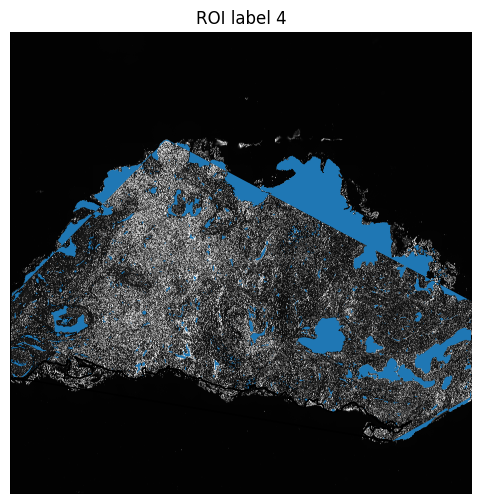

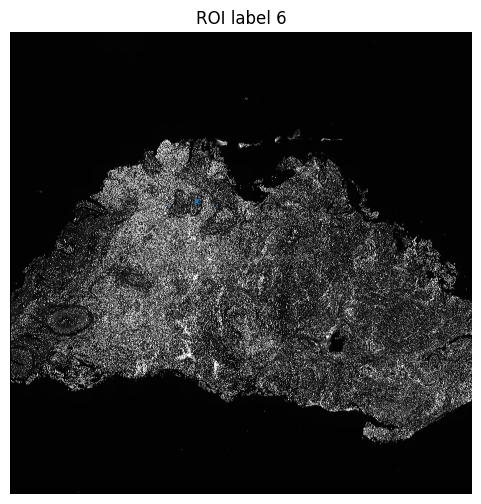

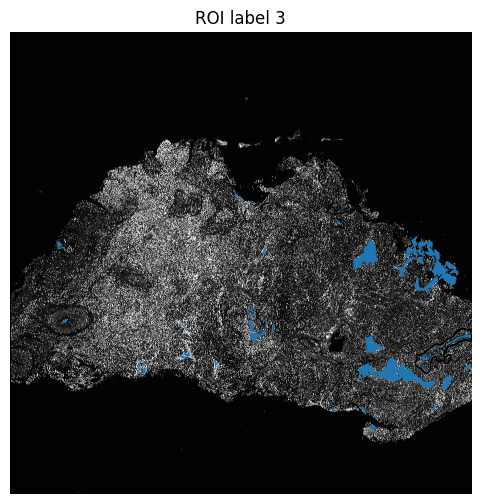

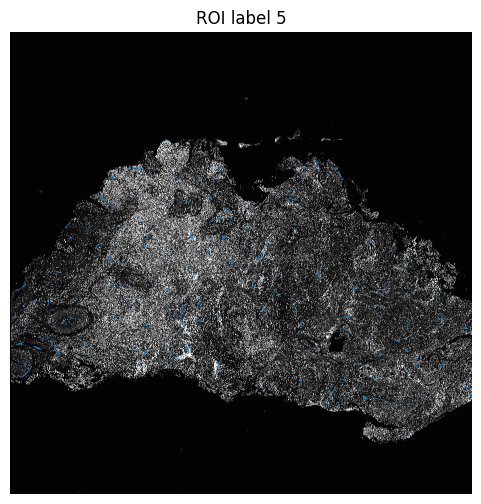

In [41]:
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

def show_overlay(image, feature):
    fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow(image, cmap="gray")
    coords = feature["geometry"]["coordinates"]  # [exterior, *holes]
    # draw exterior
    ext = np.array(coords[0])
    ax.add_patch(MplPolygon(ext, fill=False, linewidth=1))
    # draw holes
    for hole in coords[1:]:
        ax.add_patch(MplPolygon(np.array(hole), fill=True, linestyle="--", linewidth=0.8))
    ax.set_title(f"ROI label {feature['properties']['label']}")
    ax.axis("off")
    plt.show()

for feat in random.sample(features, k=min(21, len(features))):
    img = np.flip(orig_img, axis=2)
    show_overlay(img[0,...], feat)

PROCESSING V_IMG TO EXTRACT SINGLE CELL MASKS AND EXTRACT PROTEIN MARKER INTENSITIES

In [ ]:
'''
import _multiprocessing
from multiprocessing import Pool, cpu_count
    
def create_batches(cell_data, batch_size): ### cell_data <= props, batch_size <= number of masks 
    for i in range(0, len(cell_data), batch_size):
        yield cell_data[i:i + batch_size]
        
@profile
def centroid_protein_intensity_extraction(args):
    batch, orig_img, single_cell, markers, save_dir, visio_object = args
    protein_df = pd.DataFrame(columns=markers + ['centroid_x', 'centroid_y'])
    
    for prop in batch:
        coords = prop.coords
        arranged_coords = arrange_vertices(coords)
        centroid = prop.centroid
        centroid_x = centroid[1]
        centroid_y = centroid[0]

        lbl = prop.label
        mask = single_cell == lbl

        protein_expression = []
        for channel in range(orig_img.shape[0]):
            #channel_img = orig_img[channel,20000:20900, 20000:20900]
            channel_img = orig_img[channel, ...]

            ### extract intensity
            mask_mtx = channel_img[mask]
            expression = mask_mtx.mean() if mask_mtx.size > 0 else 0
            protein_expression.append(expression)

        protein_expression.append(centroid_x)
        protein_expression.append(centroid_y)

        protein_df.loc[lbl] = protein_expression

    csv_file_path = os.path.join(save_dir, f"{visio_object.split('.tif')[0]}_protein_intensity.csv")
    write_header = not os.path.exists(csv_file_path)
    protein_df.to_csv(csv_file_path, index=False, header=write_header)
    
    return None


### add tqdm

for visio_object in tqdm(visio_objects, desc="Processing visio objects"):
    v_img = tiff.imread(os.path.join(visio_out, visio_object))
    #single_cell = v_img[0,20000:20900, 20000:20900]
    single_cell = v_img[0,...]
    single_cell = label(single_cell > 0)
    props = regionprops(single_cell)

    try:
        orig_img = [tiff.imread(os.path.join(image_path, img)) for img in orig_images if visio_object.split('.tif')[0] in img][0]

    except IndexError:
        continue

    batches = list(create_batches(props, batch_size=90))
    args_list = [(batch, orig_img, single_cell, markers, save_dir, visio_object) for batch in batches]

    with Pool(processes=9) as pool:
        results = list(tqdm(pool.map(centroid_protein_intensity_extraction, args_list), 
                       total=len(args_list), desc="Processing batches"))

        ### combine results
        #combined_results = pd.concat(results, axis=0)

        # Save combined results
        #combined_results.to_csv(csv_file_path)
        
'''

In [ ]:
### Original code for single-threaded processing

for visio_object in visio_objects[-1:]:
    v_img = tiff.imread(os.path.join(visio_out, visio_object))
    v_img = np.flip(v_img, axis=2)
    single_cell = v_img[0,...]
    single_cell = label(single_cell > 0)
    props = regionprops(single_cell)

    try:
        orig_img = [tiff.imread(os.path.join(image_path, img)) for img in orig_images if visio_object.split('.tif')[0] in img][0]

    except IndexError:
        continue
    
    ### protein_df with markers as column names  
    #protein_df = pd.DataFrame(columns=markers+ ['centroid_x', 'centroid_y'])
    coordinates = []
    
    for prop in props[3001:3600]:
        coords = prop.coords
        arranged_coords = arrange_vertices(coords)
        centroid = prop.centroid
        centroid_x = centroid[1]
        centroid_y = centroid[0]

        df = pd.DataFrame({'vertex_x': [arranged_coords[:,]], 
                           'vertex_y': [arranged_coords[:,1]],
                           'cell_id': [prop.label]})
        #df['cell_id'] = prop.label

      

        coordinates.append(df)

        #lbl = prop.label
        #mask = single_cell == lbl

        #protein_expression = []
        #for channel in range(orig_img.shape[0]):
        #    channel_img = orig_img[channel, ...]
            
            ### extract intensity
        #    mask_mtx = channel_img[mask]
        #    expression = mask_mtx.mean() if mask_mtx.size > 0 else 0
        #    protein_expression.append(expression)
            
        #protein_expression.append(centroid_x)
        #protein_expression.append(centroid_y)

        #protein_df.loc[lbl] = protein_expression
        
    #protein_df['cell_id'] = protein_df.index
    #protein_df.to_csv(f'{save_dir}/{visio_object.split(".tif")[0]}.csv')

    #coordinates1 = coordinates1.explode(['vertex_x', 'vertex_y'])
    
    #coordinates1.to_csv(f'{save_dir_csv_polygons}/{visio_object.split(".tif")[0]}_vertices.csv', index=False)


In [48]:
coordinates1 = pd.concat(coordinates, axis=0)

#coordinates1 = coordinates1.explode(['vertex_x', 'vertex_y'])

In [49]:
coordinates1

,vertex_x,vertex_y,cell_id
0,"[[11116, 27555], [11117, 27554], [11118, 27553...","[27555, 27554, 27553, 27552, 27551, 27550, 275...",3002
0,"[[11125, 27601], [11124, 27600], [11123, 27599...","[27601, 27600, 27599, 27598, 27597, 27596, 275...",3003
0,"[[11125, 12128], [11123, 12127], [11124, 12127...","[12128, 12127, 12127, 12126, 12124, 12123, 121...",3004
0,"[[11122, 12812], [11121, 12811], [11119, 12810...","[12812, 12811, 12810, 12810, 12809, 12800, 127...",3005
0,"[[11118, 12830], [11119, 12830], [11120, 12827...","[12830, 12830, 12827, 12826, 12824, 12823, 128...",3006
...,...,...,...
0,"[[11276, 12776], [11275, 12774], [11274, 12773...","[12776, 12774, 12773, 12759, 12757, 12756, 127...",3596
0,"[[11281, 13322], [11278, 13321], [11279, 13321...","[13322, 13321, 13321, 13321, 13320, 13319, 133...",3597
0,"[[11275, 13587], [11276, 13587], [11277, 13587...","[13587, 13587, 13587, 13586, 13584, 13584, 135...",3598
0,"[[11274, 13640], [11275, 13639], [11276, 13638...","[13640, 13639, 13638, 13638, 13638, 13638, 136...",3599


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

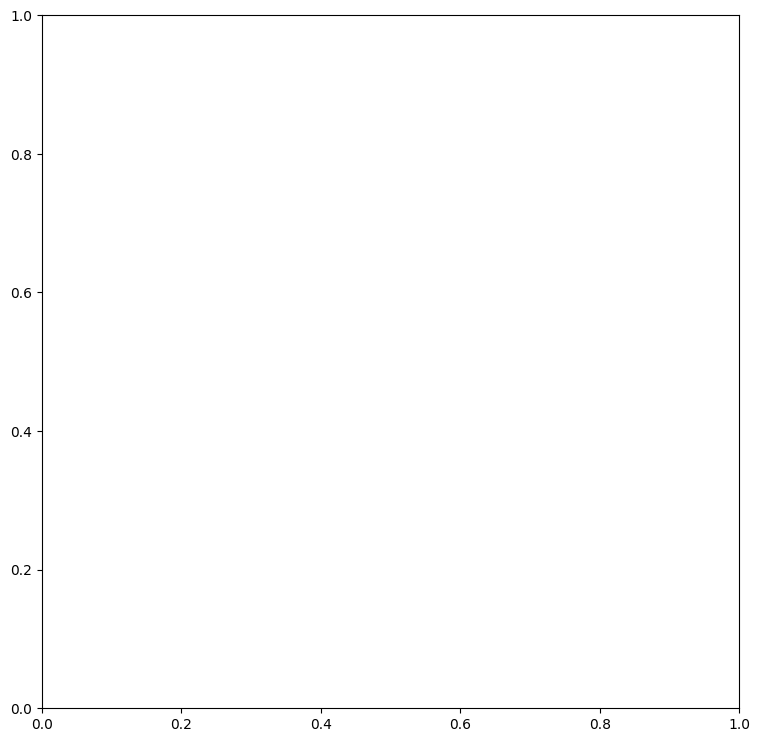

In [44]:
from matplotlib.patches import Polygon as MplPolygon

ymin, ymax = 25000, 27000
xmin, xmax = 11000, 11500

# crop
#img = np.flip(orig_img, axis=2)  # flip x-axis to match visio output
#crop = img[0, ymin:ymax, xmin:xmax]

fig, ax = plt.subplots(figsize=(9,9))
#ax.imshow(crop, cmap='gray',
#          extent=[xmin, xmax, ymin, ymax])  # ymin,ymax in normal order

grouped = coordinates1.groupby('cell_id')
for _, grp in grouped:
    polygon = MplPolygon(grp[['vertex_x','vertex_y']].values,
                         closed=True, facecolor='none', edgecolor='red', lw=1, alpha=0.5)
    ax.add_patch(polygon)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
plt.show()